## Iteration 1

### Preprocessing

For this iteration, I will not incorporate additional preprocessing steps apart from hot encoding the y labels. This decision stems from the fact that  I implemented most of the preprocessing when loading the dataset in the Responsible AI notebook. Within that task, I ensured that each class contained around 200 images, confirmed they were all in RGB format, and resized and normalized the pixels.

In [461]:
from tensorflow.keras.utils import to_categorical

# Convert integer labels to one-hot encoded vectors
v1_y_train_onehot = to_categorical(y_train)
v1_y_val_onehot = to_categorical(y_val)
v1_y_test_onehot = to_categorical(y_test)

In [462]:
v1_X_train = X_train
v1_y_train = v1_y_train_onehot
v1_X_val = X_val
v1_y_val = v1_y_val_onehot
v1_X_test = X_test
v1_y_test = v1_y_test_onehot

### CNN Architecture

In this iteration, I will implement a straightforward CNN architecture utilizing Conv2D, MaxPooling, Dropout, BatchNormalization, and early stopping. This will serve as the foundation for the iterative improvement of the overall CNN architecture structure. As we progress, I will enhance and refine the architecture to optimize its performance.

In [463]:
import tensorflow as tf
from tensorflow.keras.layers import MaxPooling2D, Conv2D
from tensorflow.keras.callbacks import EarlyStopping

In [464]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

# Define your model
v1_model = Sequential()

# Convolutional layers
v1_model.add(Conv2D(256, kernel_size=(3, 3), activation='relu', input_shape=(128, 128, 3)))
v1_model.add(MaxPooling2D(pool_size=(2, 2)))
v1_model.add(BatchNormalization())
v1_model.add(Conv2D(256, kernel_size=(3, 3), activation='relu'))
v1_model.add(MaxPooling2D(pool_size=(2, 2)))
v1_model.add(BatchNormalization())
v1_model.add(Conv2D(128, kernel_size=(3, 3), activation='relu'))
v1_model.add(MaxPooling2D(pool_size=(2, 2)))
v1_model.add(BatchNormalization())
v1_model.add(Conv2D(256, kernel_size=(3, 3), activation='relu'))
v1_model.add(MaxPooling2D(pool_size=(2, 2)))
v1_model.add(BatchNormalization())

# Flatten layer
v1_model.add(Flatten())

# Dense layers
v1_model.add(Dense(512, activation='relu'))
v1_model.add(Dropout(0.5))
v1_model.add(BatchNormalization())
v1_model.add(Dense(256, activation='relu'))
v1_model.add(Dropout(0.5))
v1_model.add(BatchNormalization())

# Output layer
v1_model.add(Dense(6, activation='softmax'))

In [465]:
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [466]:
v1_model.compile('adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [467]:
v1_model.summary()

Model: "sequential_58"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_102 (Conv2D)         (None, 126, 126, 256)     7168      
                                                                 
 max_pooling2d_123 (MaxPooli  (None, 63, 63, 256)      0         
 ng2D)                                                           
                                                                 
 batch_normalization_90 (Bat  (None, 63, 63, 256)      1024      
 chNormalization)                                                
                                                                 
 conv2d_103 (Conv2D)         (None, 61, 61, 256)       590080    
                                                                 
 max_pooling2d_124 (MaxPooli  (None, 30, 30, 256)      0         
 ng2D)                                                           
                                                     

### CNN Training

In [470]:
# Train the model
v1_history = v1_model.fit(v1_X_train, v1_y_train, epochs=32, batch_size=16, validation_data=(v1_X_val, v1_y_val), callbacks=[early_stopping])

# Evaluate the model on the test set
test_loss, test_accuracy = v1_model.evaluate(v1_X_test, v1_y_test)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Epoch 1/32


53/53 [==============================] - 38s 713ms/step - loss: 2.0001 - accuracy: 0.2821 - val_loss: 3.3772 - val_accuracy: 0.1542
Epoch 2/32
53/53 [==============================] - 40s 754ms/step - loss: 1.9149 - accuracy: 0.2893 - val_loss: 3.0436 - val_accuracy: 0.1583
Epoch 3/32
53/53 [==============================] - 40s 761ms/step - loss: 1.7980 - accuracy: 0.3381 - val_loss: 3.3315 - val_accuracy: 0.2208
Epoch 4/32
53/53 [==============================] - 40s 752ms/step - loss: 1.8058 - accuracy: 0.3226 - val_loss: 3.0228 - val_accuracy: 0.2167
Epoch 5/32
53/53 [==============================] - 40s 758ms/step - loss: 1.7398 - accuracy: 0.3452 - val_loss: 3.2608 - val_accuracy: 0.1833
Epoch 6/32
53/53 [==============================] - 40s 756ms/step - loss: 1.6445 - accuracy: 0.3798 - val_loss: 3.1193 - val_accuracy: 0.2000
Epoch 7/32
53/53 [==============================] - 41s 767ms/step - loss: 1.5281 - accuracy: 0.4238 - val_loss: 2.7561 - val_accuracy: 0.2375
Epoch 8/32

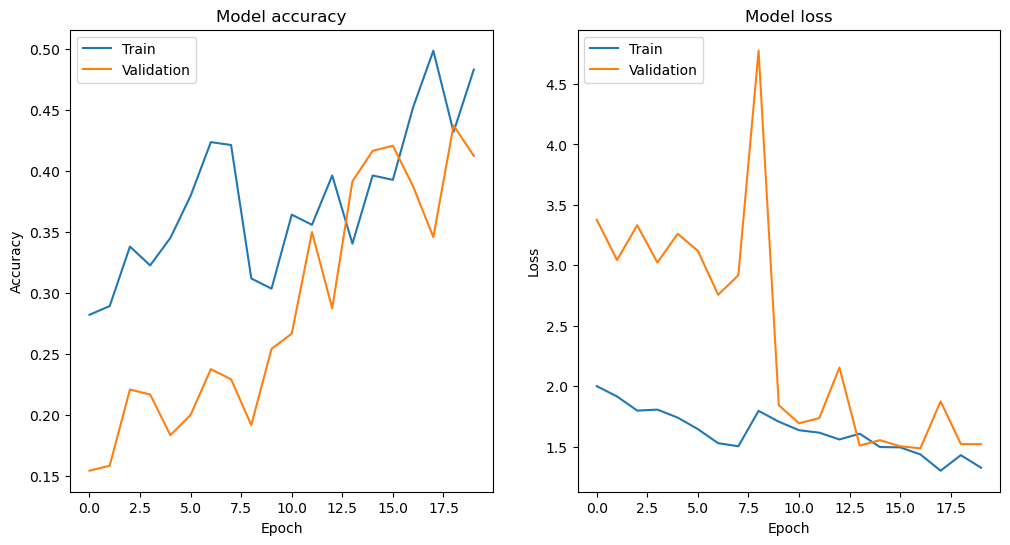

In [933]:
# Plot learning curves
def plot_learning_curves(v1_history):
    plt.figure(figsize=(12, 6))

    # Plot training & validation accuracy values
    plt.subplot(1, 2, 1)
    plt.plot(v1_history.history['accuracy'])
    plt.plot(v1_history.history['val_accuracy'])
    plt.title('Model accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(['Train', 'Validation'], loc='upper left')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(v1_history.history['loss'])
    plt.plot(v1_history.history['val_loss'])
    plt.title('Model loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(['Train', 'Validation'], loc='upper left')

    plt.show()

plot_learning_curves(v1_history)

### Model Performance

In [472]:
from sklearn.metrics import precision_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


def evaluate_model(model, X_test, y_test):
    y_pred_prob = model.predict(X_test)
    
    # Convert probabilities to class labels
    if len(y_pred_prob.shape) > 1 and y_pred_prob.shape[1] > 1:
        y_pred = np.argmax(y_pred_prob, axis=1)
    else:
        y_pred = y_pred_prob.round().astype(int)
    
    # Convert y_test to one-hot encoded format if needed
    if len(y_test.shape) > 1 and y_test.shape[1] > 1:
        y_test_label = np.argmax(y_test, axis=1)
    else:
        y_test_label = y_test
    
    accuracy = accuracy_score(y_test_label, y_pred)
    precision = precision_score(y_test_label, y_pred, average='weighted', zero_division=1)
    recall = recall_score(y_test_label, y_pred, average='weighted')
    f1 = f1_score(y_test_label, y_pred, average='weighted')
    cm = confusion_matrix(y_test_label, y_pred)
    return accuracy, precision, recall, f1, cm

# Assuming you have defined v1_model and mlp

# Evaluate v1_model and mlp
models = [v1_model, mlp]  # Only v1_model and mlp
X_tests = [v1_X_test, mlp_X_test]  # Test data for v1_model and mlp
y_tests = [v1_y_test, mlp_y_test]  # Test labels for v1_model and mlp

for i, model in enumerate(models):
    print(f"Model {i+1}:")
    accuracy, precision, recall, f1, cm = evaluate_model(model, X_tests[i], y_tests[i])
    print("Confusion Matrix:")
    print(cm)
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("=" * 50)


Model 1:
4/4 [==============================] - 1s 299ms/step
Confusion Matrix:
[[ 8  1  3  2  0  0]
 [ 2  6  5  5  2  2]
 [ 2  0 15  2  1  1]
 [ 2  3  7  6  2  1]
 [ 1  1 11  0  6  5]
 [ 0  2  5  0  2  9]]
Accuracy: 0.4167
Precision: 0.4412
Recall: 0.4167
F1 Score: 0.4038
Model 2:
4/4 [==============================] - 0s 9ms/step
Confusion Matrix:
[[6 1 4 0 1 2]
 [3 8 3 1 0 7]
 [4 5 6 0 1 5]
 [1 7 4 1 0 8]
 [3 6 4 0 2 9]
 [1 2 6 0 0 9]]
Accuracy: 0.2667
Precision: 0.3496
Recall: 0.2667
F1 Score: 0.2354


### Error Analysis

2/8 [======>.......................] - ETA: 2s

8/8 [==============================] - 3s 310ms/step


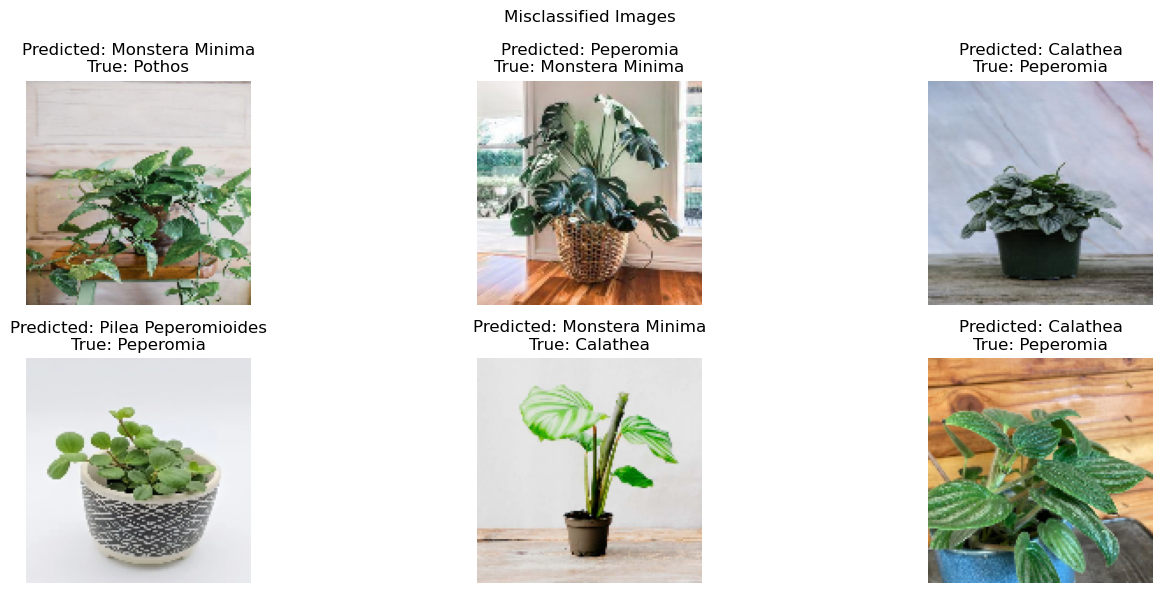

In [948]:
import numpy as np
import matplotlib.pyplot as plt

def plot_wrong_classifications(images, predicted_labels, true_labels, class_names, num_examples=6):
    # Find the indices of misclassified images
    misclassified_indices = np.where(predicted_labels != true_labels)[0]
    num_misclassified = len(misclassified_indices)
   
    if num_misclassified == 0:
        print("No misclassifications found.")
        return
   
    num_examples = min(num_examples, num_misclassified)
   
    # Shuffle the indices of misclassified images
    np.random.shuffle(misclassified_indices)
    
    # Create subplots to display the misclassified images
    fig, axes = plt.subplots(2, num_examples // 2, figsize=(15, 6))
    fig.suptitle('Misclassified Images')
   
    # Iterate over each misclassified image
    for i, idx in enumerate(misclassified_indices[:num_examples]):
        # Compute the row and column indices
        row = i // (num_examples // 2)
        col = i % (num_examples // 2)
        
        # Display the image
        axes[row, col].imshow(images[idx])
        
        # Set the title of the subplot with predicted and true labels
        axes[row, col].set_title(f"Predicted: {class_names[predicted_labels[idx]]}\nTrue: {class_names[true_labels[idx]]}")
        
        # Hide axis ticks
        axes[row, col].axis('off')
   
    # Adjust layout
    plt.tight_layout()
   
    # Show the plot
    plt.show()

# Make predictions on the validation set
v1_predictions = v1_model.predict(v1_X_val)
v1_true_labels = np.argmax(v1_y_val, axis=1)
v1_predicted_labels = np.argmax(predictions, axis=1)

# Plot misclassified images
plot_wrong_classifications(v1_X_val, v1_predicted_labels, v1_true_labels, class_names, num_examples=6)


In [949]:
def analyze_errors(images, predicted_labels, true_labels, class_names):
    # Initialize dictionaries to store misclassified images for each category
    misclassified_by_class = {class_name: [] for class_name in class_names}
    misclassified_by_visual_characteristics = {}

    # Find the indices of misclassified images
    misclassified_indices = np.where(predicted_labels != true_labels)[0]

    # Iterate over misclassified images
    for idx in misclassified_indices:
        predicted_class = class_names[predicted_labels[idx]]
        true_class = class_names[true_labels[idx]]

        # Categorize misclassifications by class
        misclassified_by_class[true_class].append(idx)

        # Categorize misclassifications by visual characteristics
        visual_characteristics = get_visual_characteristics(images[idx])
        misclassified_by_visual_characteristics.setdefault(visual_characteristics, []).append(idx)

    return misclassified_by_class, misclassified_by_visual_characteristics

# Example function to extract visual characteristics (replace with your own logic)
def get_visual_characteristics(image):
    # Example: Return the average color of the image
    average_color = np.mean(image, axis=(0, 1))
    return tuple(average_color)

# Call the function to analyze errors
misclassified_by_class, misclassified_by_visual_characteristics = analyze_errors(v1_X_val, v1_predicted_labels, v1_true_labels, class_names)

# Summarize findings from error analysis
print("Misclassified by Class:")
for true_class, misclassified_indices in misclassified_by_class.items():
    print(f"Class: {true_class}, Misclassified Count: {len(misclassified_indices)}")



Misclassified by Class:
Class: Cactus, Misclassified Count: 3
Class: Calathea, Misclassified Count: 9
Class: Monstera Minima, Misclassified Count: 9
Class: Peperomia, Misclassified Count: 17
Class: Pilea Peperomioides, Misclassified Count: 8
Class: Pothos, Misclassified Count: 8


The first iteration got an accuracy of 42% and has a somewhat off misclassification count. This suggests significant misclassification errors occurring in the model. Occurs when the model architecture is not complex enough. Because the model has a very simple architecture it may struggle to learn specific and detailed patterns and features required for an accurate classification. Furthermore, the dataset is very small and can therefore not effectively train the model.

To address this issue, I will apply data augmentation in the next step in the hope to improve its performance


## MLP From Scratch

Importing libaries

In [908]:
from skimage import io as ski_io
import os
import numpy as np
import skimage as ski
import random
from sklearn import preprocessing

In [ ]:
# Defining the directory containing the dataset
datasets = str("../GitHub/Google-Image-Scraper/photos")

# Folder paths to the images of each class are stored
folder_paths = [
    r"C:/../GitHub/Google-Image-Scraper/photos/Cactus",
    r"C:/../GitHub/Google-Image-Scraper/photos/Calathea",
    r"C:/../GitHub/Google-Image-Scraper/photos/Monstera Minima",
    r"C:/../GitHub/Google-Image-Scraper/photos/Peperomia",
    r"C:/../GitHub/Google-Image-Scraper/photos/Pilea Peperomioides",
    r"C:/../GitHub/Google-Image-Scraper/photos/Pothos"
]

# Class labels for the images (same order as folder_paths)
class_names = [
    "Cactus", "Calathea", "Monstera Minima", "Peperomia", "Pilea Peperomioides", "Pothos"
]

In [910]:
# Target size to resize the images
target_size = (16, 16)

# Arrays to store the images (X) and class labels (y)
X = []
y = []

Preprocessing the dataset to ensure that all classes contain approximately 200 images and that they are all in RGB format

In [912]:
import os
from PIL import Image
import numpy as np

# Function that makes sure that the images are in RGB format
def is_rgb_image(image_path):
    try:
        with Image.open(image_path) as img:
            if img.mode == 'RGB':
                return True
            elif img.mode == 'RGBA':
                # Convert RGBA to RGB
                img = img.convert("RGB")
                return True
            else:
                return False
    except Exception as e:
        print(f"Error: {e}")
        return False
# Specify the number of images to be loaded
num_images_per_folder = 200
target_size = (16, 16)

for i in range(len(folder_paths)):
    # List all files in the folder
    files = os.listdir(folder_paths[i])
    # Select 20 files randomly
    files_to_load = random.sample(files, min(num_images_per_folder, len(files)))
    for filename in files_to_load:
        file_extension = os.path.splitext(filename)[1]
        # Check if the file extension is an image extension
        if file_extension.lower() in ['.jpg', '.jpeg', '.png']:
            image_filename = os.path.join(folder_paths[i], filename)
            # Check if the image is in RGB format
            if is_rgb_image(image_filename):
                # Read the image file using scikit-image
                image = ski_io.imread(image_filename, as_gray=True)
                # Resize the image to the target_size
                image_resized = ski_transform.resize(image, target_size)
                if image_resized.shape == (16, 16):
                    # Insert the image into array X
                    X.append(image_resized)
                    # Insert the class label into array y
                    y.append(class_names[i])

# Convert arrays into numpy arrays
X = np.array(X)
y = np.array(y)

In [913]:
# Initialize LabelEncoder with class names
label_encoder = LabelEncoder()
label_encoder.classes_ = np.array(class_names)

# Encode class labels
y_integer_encoded = label_encoder.transform(y)

# Convert integer-encoded labels into one-hot encoded vectors
def to_one_hot(labels, num_classes):
    num_samples = len(labels)
    one_hot_encoded = np.zeros((num_samples, num_classes))
    one_hot_encoded[np.arange(num_samples), labels] = 1
    return one_hot_encoded

y_onehot_encoded = to_one_hot(y_integer_encoded, len(class_names))

# Split the data into train, test, and validation sets
X_train, X_test_val, y_train, y_test_val = train_test_split(X, y_onehot_encoded, test_size=0.1, random_state=0)
X_test, X_val, y_test, y_val = train_test_split(X_test_val, y_test_val, test_size=2/9, random_state=0)

# Reshape the input data
X_train_reshaped = X_train.reshape(-1, 16*16)
X_test_reshaped = X_test.reshape(-1, 16*16)
X_val_reshaped = X_val.reshape(-1, 16*16)

The following function iterates over the layers of the architecture, except the output layer, and initializes the weights and biases for each layer randomely using a Gaussian distribution. 

In [914]:
from copy import deepcopy

def initializer(mlps_architecture):
    weights = []
    biases = []

    for l in range(0, len(mlps_architecture)-1):
        w = np.random.randn(mlps_architecture[l], mlps_architecture[l+1])
        weights.append(w)
        b = np.random.randn(1, mlps_architecture[l+1])
        biases.append(b)

    return weights, biases

The softmax function converts the raw scores (logits) of the neural network's output layer into probabilities for multi-class classification tasks. 

In [915]:
def softmax(x):
    # Subtracting the maximum value from each element for numerical stability
    exp_scores = np.exp(x - np.max(x, axis=1, keepdims=True))
    # Compute softmax probabilities
    softmax_probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
    return softmax_probs

In [916]:
def predict(X, weights, biases):
    '''
    This function is used to make predictions using the mlps_architecture with given weights and biases. 

    '''
    layer_input = X
    for i in range(len(weights)):
        layer_output = sigmoid(np.dot(layer_input, weights[i]) + biases[i])
        layer_input = layer_output
    y_pred = layer_output

    return y_pred

In [917]:
def accuracy(y_pred_binary, y):
    '''
    Calculates the accuracy of mlps_architecture

    '''
    return sum(y_pred_binary == y)/len(y)

In [918]:
def loss_function(X, y, weights, biases):
    losses = []
    for i in range(len(X)):
        prediction = predict(X[i], weights, biases)
        # Avoid numerical instability by clipping probabilities
        epsilon = 1e-15
        prediction = np.clip(prediction, epsilon, 1 - epsilon)
        # Cross-entropy loss calculation
        loss = -np.sum(y[i] * np.log(prediction))
        losses.append(loss)

    return np.mean(losses)

In [919]:
def weight_update(weights, layer_id, i, j, new_param):
    # It is important to create a copy of the weights and update the copy
    new_w = deepcopy(weights)

    layer_w = weights[layer_id]
    new_layer_w = layer_w.copy()
    new_layer_w[i, j] = new_param
    new_w[layer_id] = new_layer_w

    return new_w

In [920]:
def bias_update(biases, layer_id, j, new_param):
    '''
    Given a single bias defined by (layer_id, j)
    updates it with a new parameter (new_param)

    Arguments
        biases: list of np.arrays()
        layer_id: integer
        j: integer
        new_param: float
    Return
        new_b: list of np.arrays()
               where only a single value is changed

    '''

    # It is important to create a copy and update the copy
    new_b = deepcopy(biases)

    layer_b = biases[layer_id]
    new_layer_b = layer_b.copy()
    new_layer_b[0, j] = new_param
    new_b[layer_id] = new_layer_b

    return new_b

In [921]:
def gradient_estimator(X, y, weights, biases):
    eps = 1e-4
    loss_val = loss_function(X, y, weights, biases)

    # partial derivatives for weights
    w_pds = []
    for layer_id, layer_w in enumerate(weights):
        pd_array = np.zeros(layer_w.shape)

        # Calculate the partial derivative (pd) for each weight
        # and save those values into pd_array

        for i in range(layer_w.shape[0]):
            for j in range(layer_w.shape[1]):

                wij = layer_w[i, j]

                wij_plus = wij + eps
                w_plus = weight_update(weights, layer_id, i, j, wij_plus)
                loss_plus = loss_function(X, y, w_plus, biases)

                pd = (loss_plus - loss_val)/eps
                pd_array[i, j] = pd

        w_pds.append(pd_array)

    # partial derivatives for biases
    b_pds = []
    for layer_id, layer_b in enumerate(biases):
        pd_array = np.zeros(layer_b.shape)

        # Calculate the partial derivative (pd) for each bias
        # and save those values into pd_array

        for j in range(layer_b.shape[1]):
            i = 0
            bij = layer_b[i, j]

            bij_plus = bij + eps
            b_plus = bias_update(biases, layer_id, j, bij_plus)
            loss_plus = loss_function(X, y, weights, b_plus)

            pd = (loss_plus - loss_val)/eps
            pd_array[i, j] = pd

        b_pds.append(pd_array)

    return w_pds, b_pds    

In [922]:
def one_step_gradient_descent(X, y, weights, biases, lr):
    '''
    This function executes one step of gradient decent and updates weights and biases.

    First estimate the gradient using the gradient_estimator function implemented
    in the previous task.

    Then, update the params by:
    w = w - lr * w_pds
    b = b - lr * b_pds

    Arguments:
        X: input data
        y: labels
        weights: NN weights
        biases: NN biases
        lr: learning rate, a float
    Returns:
        new_w: updated weights, same size as weights
        new_b: updated biases, same size as biases

    '''
    w_pds, b_pds = gradient_estimator(X, y, weights, biases)

    new_w = []
    # For each weight array in weights list
    # use gradient descent update rule
    # append the array to new_w list

 
    for layer_id, layer_w in enumerate(weights):
        layer_new_w = layer_w - lr*w_pds[layer_id]
        new_w.append(layer_new_w)


    new_b = []
    # For each bias array in biases list
    # use gradient descent update rule
    # append the array to new_b list

    for layer_id, layer_b in enumerate(biases):
        layer_new_b = layer_b - lr*b_pds[layer_id]
        new_b.append(layer_new_b)
    return new_w, new_b

In [923]:
def gradient_descent(X, y, weights, biases, epoch, lr):
    errors = []

    for i in range(epoch):
        weights, biases = one_step_gradient_descent(X, y, weights, biases, lr)
        error = loss_function(X, y, weights, biases)
        errors.append(error)

    plt.figure(dpi=200)
    plt.plot(errors)
    plt.xlabel('# epochs')
    plt.ylabel('loss')

    return weights, biases

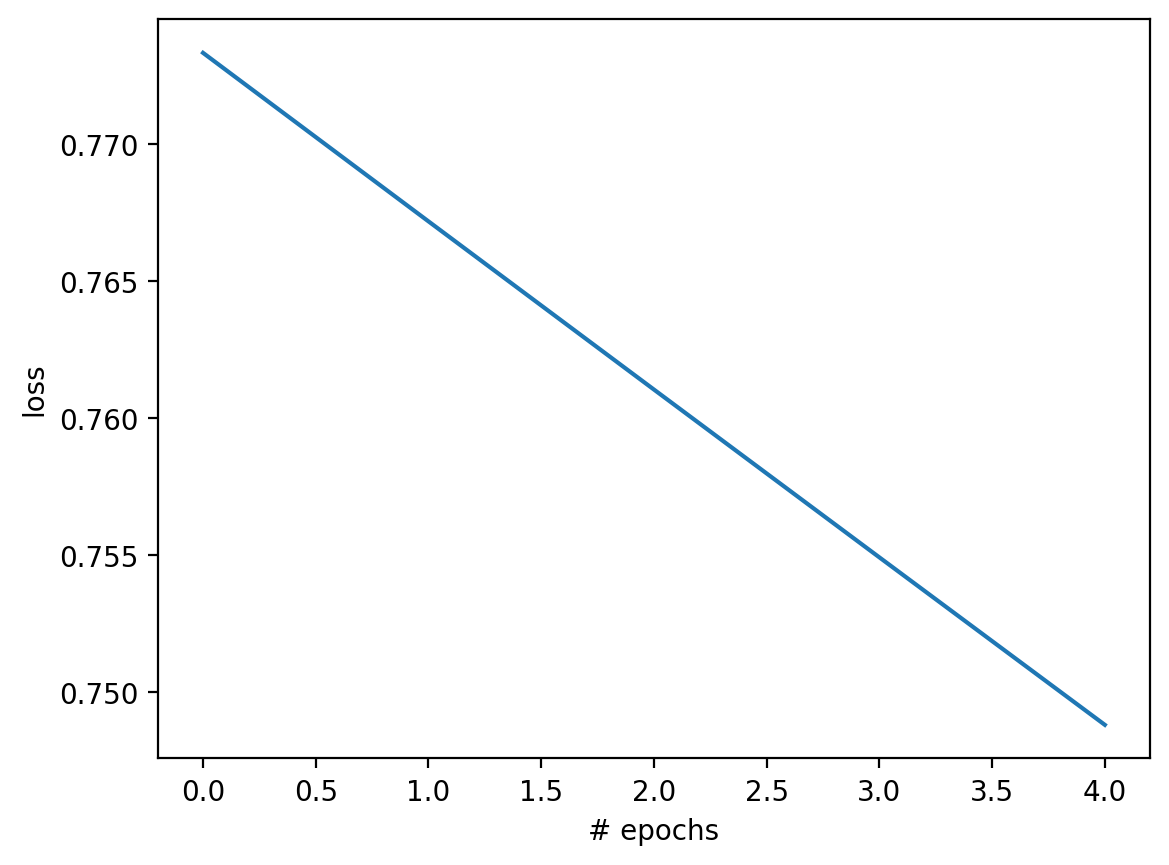

In [925]:
# Define MLP architecture
mlps_architecture = [X_train_reshaped.shape[1], 64, 6]

# Initialize weights and biases
weights, biases = initializer(mlps_architecture)

# Train the MLP using gradient descent
trained_weights, trained_biases = gradient_descent(X_train_reshaped, y_train, weights, biases, epoch=5, lr=0.01)


In [932]:
print("Test Accuracies by Class:")
for i, class_accuracy in enumerate(test_accuracy):
    print(f"Class {i}: {class_accuracy:.2f}")

Test Accuracies by Class:
Class 0: 0.27
Class 1: 0.27
Class 2: 0.08
Class 3: 0.18
Class 4: 0.87
Class 5: 0.15
